2025-12-15 创建
1. 解决风-浪场的预报功能
2. 使用U-Net CNN神经网络
3. 加入了Boosting机制

In [1]:
import os
import subprocess
import sys

# === 关键：这段代码必须放在 import torch 之前运行 ===
def get_freest_gpu():
    try:
        # 查询显存剩余量
        result = subprocess.check_output(
            "nvidia-smi --query-gpu=memory.free --format=csv,nounits,noheader",
            shell=True, text=True)
        free_mems = [int(x) for x in result.strip().split('\n')]
        # 找到剩余内存最大的 GPU 索引
        best_gpu = free_mems.index(max(free_mems))
        return best_gpu
    except Exception as e:
        print(f"自动选择 GPU 失败: {e}，将使用默认 GPU 0")
        return 0

# 获取最空闲的 GPU
best_gpu = get_freest_gpu()

# 设置环境变量（必须在 import torch 之前！）
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = str(best_gpu)
print(f"已设置 CUDA_VISIBLE_DEVICES = {best_gpu} (物理 GPU)")

# === 之后再导入 torch ===
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
# 自建函数库
from main_python_MyFunctions import c_PickleHandler

# 检查当前 PyTorch 看到的设备
# 如果设置成功，torch.cuda.current_device() 应该是 0，但它对应的是物理 GPU 1
if torch.cuda.is_available():
    print(f"PyTorch 当前使用设备: cuda:0")
    print(f"该设备属性: {torch.cuda.get_device_name(0)}")


已设置 CUDA_VISIBLE_DEVICES = 0 (物理 GPU)
PyTorch 当前使用设备: cuda:0
该设备属性: NVIDIA GeForce RTX 4090 D


# 数据处理环节

In [2]:
import f_FilesMethods
# 加载台风id数据
id = f_FilesMethods.read_matlab_mat('../datas/Id.mat', 'Id')

## 加载数据

### 加载pkl数据
文件路径../datas/*.pkl

二维为*_2d.pkl；一维为*_piled.pkl

In [3]:
import gc  # 关键：手动垃圾回收

def f_load_pickle(file_path):
    handle = c_PickleHandler(file_path)
    data = handle.load_data()
    return data

   
# 读取文件
print('**loading files ...')

# env_type = input("Please input the environment type (wave, surge, current): ")
env_type = 'wave'  # 'wave' ,'surge', 'current'

# 读取mat文件
wind_2d = f_load_pickle('../datas/wind_2d.pkl')
if env_type == 'surge':
    output_map_2d = f_load_pickle('../datas/surge_2d.pkl')
elif env_type == 'current':
    surge_2d = f_load_pickle('../datas/surge_2d.pkl')
    current_2d = f_load_pickle('../datas/current_2d.pkl')
elif env_type == 'wave':
    output_map_2d = f_load_pickle('../datas/wave_2d.pkl')

# 立即释放大对象
del f_load_pickle
gc.collect()

# 查询surge_piled绝对值大于3的值的索引
# 只保留绝对值小于3的风暴潮数据
if env_type == 'surge':
    print('**cleaning surge data ...')
    # fvcom中有计算发散的场次，他们的风暴潮最小值为非常大的负值
    output_2d_min = np.nanmin(output_map_2d, axis=(1,2))
    extreme_indices = np.where(output_2d_min < -1000)[0]
    output_map_2d[extreme_indices, :, :] = np.nan
    del output_2d_min, extreme_indices
    gc.collect()
elif env_type == 'current':
    print('**cleaning current data ...')
    # fvcom中有计算发散的场次，他们的风暴潮最小值为非常大的负值
    surge_2d_min = np.nanmin(surge_2d, axis=(1,2))
    extreme_indices = np.where(surge_2d_min < -1000)[0]
    current_2d[extreme_indices, :, :] = np.nan
    del surge_2d, surge_2d_min, extreme_indices
    gc.collect()

# 正确提取 wind_2d 的 real 和 imag（关键修复：用 fields 访问）
wind_real = wind_2d['real'].astype(np.float32)  # (110387, 56, 54), 纯 float64
wind_imag = wind_2d['imag'].astype(np.float32)  # 同上
wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (110387, 2, 56, 54), 纯 float64
# 清理原始 dict
del wind_2d, wind_real, wind_imag
gc.collect()

# current 处理（如果适用）
if env_type == 'current':
    current_real = current_2d['real'].astype(np.float64)
    current_imag = current_2d['imag'].astype(np.float64)
    output_map_2d = np.stack([current_real, current_imag], axis=1)
    del current_2d, current_real, current_imag
    gc.collect()


# 网格数据
# x = np.arange(105.3, 116.01, 0.2, dtype = float)
# y = np.arange(12, 23.01, 0.2, dtype = float)
x = np.linspace(105.3, 116.0, 64, dtype = float)
y = np.linspace(12.0, 23.0, 64, dtype = float)
X,Y = np.meshgrid(x, y)

print("Data loading fixed: wind_combined dtype =", wind_combined.dtype)  # 应为 float64
print("Data loading fixed: wind_combined shape =", wind_combined.shape)
if env_type == 'surge':
    print("data type (surge): ",output_map_2d.dtype)
elif env_type == 'current':
    print("data type (current): ",output_map_2d.dtype)
elif env_type == 'wave':
    print("data type (wave): ",output_map_2d.dtype)

**loading files ...
Data loading fixed: wind_combined dtype = float32
Data loading fixed: wind_combined shape = (109580, 2, 64, 64)
data type (wave):  float64


In [4]:
# 分析output_map_2d在axis=0上的最小值
if env_type == 'surge' or env_type == 'wave':
    output_2d_min = np.nanmin(output_map_2d, axis=(1,2))
    print("output_map_2d min along axis 0:", output_2d_min)
# 查询output_2d_min中小于-1000的值的索引
    extreme_indices = np.where(output_2d_min < -1000)[0]
    print("Indices with extreme low values (< -1000):", extreme_indices)

output_map_2d min along axis 0: [0. 0. 0. ... 0. 0. 0.]
Indices with extreme low values (< -1000): []


### 检查数据异常值
报告数据异常值数量

In [5]:
# 检查原始数据中的 NaN/Inf
print("Wind data stats:")
print(f"NaN in wind: {np.any(np.isnan(wind_combined))}")
print(f"Inf in wind: {np.any(np.isinf(wind_combined))}")

print("\nOutput data stats:")
print(f"NaN in output_map_2d: {np.any(np.isnan(output_map_2d))}")
print(f"Inf in output_map_2d: {np.any(np.isinf(output_map_2d))}")

# 示例：打印有 NaN 的样本索引（如果有）
nan_wind_idx = np.where(np.isnan(wind_combined).any(axis=(1,2,3)))
nan_output_idx = np.where(np.isnan(output_map_2d).any(axis=(1,2)))
print(f"Wind NaN samples: {len(nan_wind_idx[0])}")
print(f"Output NaN samples: {len(nan_output_idx[0])}")

# 如果有 NaN，查看范围
print(f"Wind min/max: {np.nanmin(wind_combined):.2f} / {np.nanmax(wind_combined):.2f}")
print(f"Output min/max: {np.nanmin(output_map_2d):.2f} / {np.nanmax(output_map_2d):.2f}")


Wind data stats:
NaN in wind: True
Inf in wind: False

Output data stats:
NaN in output_map_2d: True
Inf in output_map_2d: False
Wind NaN samples: 109580
Output NaN samples: 109580
Wind min/max: -66.02 / 67.88
Output min/max: 0.00 / 26.55


### 清除数据异常值并进行归一化

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 清理 NaN/Inf：替换为 0（或均值），或删除样本
# 选项1: 替换（简单，保留所有样本）
# wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
# output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0)
output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0)
del wind_combined, output_map_2d
gc.collect()

N, C, H, W = wind_combined_clean.shape

print("Cleaned data stats:")
print(f"NaN in cleaned wind: {np.any(np.isnan(wind_combined_clean))}")
print(f"NaN in cleaned output: {np.any(np.isnan(output_map_2d_clean))}")

# 全局归一化：将所有样本和空间位置一起归一化
'''wind_reshaped = wind_combined_clean.transpose(0, 2, 3, 1).reshape(-1, C)
print(f"Wind reshaped for global scaling: {wind_reshaped.shape}") # 应该是 (*, 2)
scaler_wind = MinMaxScaler(feature_range=(-1, 1))
# 注意：transform 接收 (M, 2)，输出 (M, 2)，需要再变回 (N, 2, 64, 64)
wind_normalized_flat = scaler_wind.fit_transform(wind_reshaped)
# 还原形状: (N*H*W, C) -> (N, H, W, C) -> (N, C, H, W)
wind_normalized = wind_normalized_flat.reshape(N, H, W, C).transpose(0, 3, 1, 2)'''
# 全局归一化：风速
wind_reshaped = wind_combined_clean.reshape(N, -1)  # (N, C*H*W)
print(f"Wind reshaped for global scaling: {wind_reshaped.shape}") # 应该是 (N, 2*56*54)
scaler_wind = MinMaxScaler(feature_range=(-1, 1))
# 注意：transform 接收 (N, D)，输出 (N, D)，需要再变回 (N, C, H, W)
wind_normalized_flat = scaler_wind.fit_transform(wind_reshaped)
# 还原形状: (N, C*H*W) -> (N, C, H, W)
wind_normalized = wind_normalized_flat.reshape(N, C, H, W)


# 立即释放内存
del wind_reshaped, wind_normalized_flat
gc.collect()

# 输出变量归一化
if env_type == 'current':
    # Current 也是 2 通道
    N, C, H, W = output_map_2d_clean.shape
    out_reshaped = output_map_2d_clean.transpose(0, 2, 3, 1).reshape(-1, C)
    
    scaler_output = MinMaxScaler(feature_range=(-1, 1))
    out_normalized_flat = scaler_output.fit_transform(out_reshaped)
    output_normalized = out_normalized_flat.reshape(N, H, W, C).transpose(0, 3, 1, 2)

    del out_reshaped, out_normalized_flat
    gc.collect()    
else:
    # Surge / Wave 是 1 通道 (N, 64, 64) -> (N*64*64, 1)
    '''output_flat = output_map_2d_clean.reshape(-1, 1)'''
    output_flat = output_map_2d_clean.reshape(N, -1)
    
    if env_type == 'surge':
        scaler_output = MinMaxScaler(feature_range=(-1, 1))
    elif env_type == 'wave':
        scaler_output = MinMaxScaler(feature_range=(0, 1))
        
    out_normalized_flat = scaler_output.fit_transform(output_flat)
    output_normalized = out_normalized_flat.reshape(output_map_2d_clean.shape)

    # 立即释放内存
    del output_flat, out_normalized_flat
    gc.collect()

# 保存wind和output的scaler
import joblib
import os
save_dir = "../datas/"
os.makedirs(save_dir, exist_ok=True)
joblib.dump(scaler_wind,   os.path.join(save_dir, "scaler_wind.joblib"))
joblib.dump(scaler_output, os.path.join(save_dir, f"scaler_{env_type}.joblib"))
print("Global Scalers saved.")

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")
print(f"Output normalized min/max: {np.nanmin(output_normalized):.2f} / {np.nanmax(output_normalized):.2f}")

Cleaned data stats:
NaN in cleaned wind: False
NaN in cleaned output: False
Wind reshaped for global scaling: (109580, 8192)
Global Scalers saved.
Normalized wind NaN: False
Normalized output NaN: False
Wind normalized min/max: -1.00 / 1.00
Output normalized min/max: 0.00 / 1.00


#### 绘制归一化风场

TC id: 200518
Same Index: 159


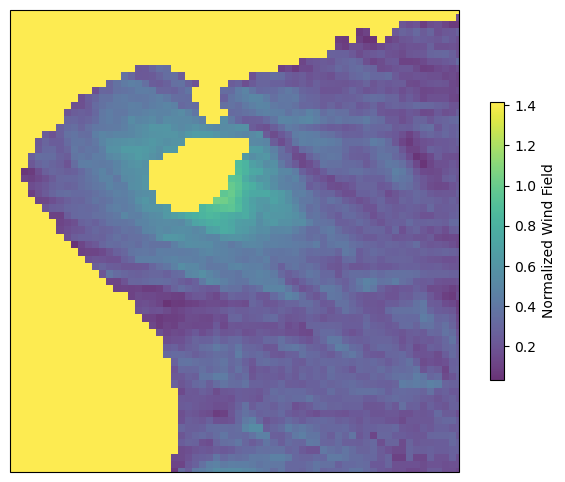

In [7]:
sample_idx = 84710# 84710 Damrey # 97480 Haiyan # 100120 Sarika # 97950 rammasun # 取第sample_idx个样本；可改成其他索引
print("TC id: %d" % id[0][sample_idx])
print(f"Same Index: {sample_idx - np.where(id[0]==id[0][sample_idx])[0][0]}")

import cartopy.crs as ccrs
wind_field_np = np.sqrt(wind_normalized[sample_idx, 0, :, :]**2 + wind_normalized[sample_idx, 1, :, :]**2)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ax.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im = ax.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im, ax=ax, label='Normalized Wind Field', shrink=0.6)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
plt.show()

## 数据转化为训练数据

In [8]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class NumpyDataset(Dataset):
    def __init__(self, wind_data, output_data):
        # 关键：只保存引用，不复制！
        self.wind_data = wind_data      # (N, 2, 56, 54) float64
        self.output_data = output_data  # (N, 56, 54) float64
        assert len(self.wind_data) == len(self.output_data), "Length mismatch!"

    def __len__(self):
        return len(self.wind_data)

    def __getitem__(self, idx):
        # 动态转换：只转换当前样本，内存极小
        wind = torch.from_numpy(self.wind_data[idx].astype(np.float32))      # (2,56,54)
        # output = torch.from_numpy(self.output_data[idx].astype(np.float32)).unsqueeze(0)  # (1,56,54)
        out_data = self.output_data[idx].astype(np.float32)
        if out_data.ndim == 2: # (H, W) -> 增加通道维 -> (1, H, W)
            output = torch.from_numpy(out_data).unsqueeze(0)
        else: # (C, H, W) -> 保持原样
            output = torch.from_numpy(out_data)
            
        return wind, output

# === 使用 ===
dataset = NumpyDataset(wind_normalized, output_normalized)
# dataset = NumpyDataset(wind_combined_resampled, output_map_resampled)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0)

print(f"Dataset size: {len(dataset)}")

Dataset size: 109580


# 模型设置

## 损失函数

- `CombinedLoss2`: MSE + L1
- `CombinedLoss3`: MSE + Gradient + Quantile
- `HighValueDiceLoss`: Dice loss for high values
- `QuantileLoss`: Single quantile loss
- `CombinedQuantileLoss`: Lower quantile + MSE + Upper quantile


In [9]:
# 损失函数
import torch
import torch.nn as nn
import torch.nn.functional as F


# 自定义损失函数：CombinedLoss (MSE + L1)
class CombinedLoss2(nn.Module):
    def __init__(self, alpha=0.5):  # alpha: MSE 权重，1-alpha: L1 权重
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        l1_loss = self.l1(pred, target)
        return self.alpha * mse_loss + (1 - self.alpha) * l1_loss

# 组合损失
class CombinedLoss3(nn.Module):
    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2):
        super().__init__()
        self.alpha = alpha  # MSE权重
        self.beta = beta    # 梯度损失权重
        self.gamma = gamma  # 分位数损失权重
        
    def forward(self, pred, target):
        # MSE损失
        mse_loss = nn.functional.mse_loss(pred, target)
        SmoothL1_loss = nn.functional.smooth_l1_loss(pred, target)
        
        # 梯度损失 - 保持空间结构
        grad_x_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
        grad_x_target = target[:, :, :, 1:] - target[:, :, :, :-1]
        grad_y_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
        grad_y_target = target[:, :, 1:, :] - target[:, :, :-1, :]
        
        grad_loss = (nn.functional.mse_loss(grad_x_pred, grad_x_target) + 
                     nn.functional.mse_loss(grad_y_pred, grad_y_target))
        
        # 分位数损失 - 关注极值
        quantiles = [0.1, 0.9]  # 低值和高值分位数
        # quantiles = [0.9]
        quantile_loss = 0
        for q in quantiles:
            errors = target - pred
            quantile_loss += torch.max(q * errors, (q-1) * errors).mean()
            # quantile_loss += torch.quantile(torch.max(q * errors, (q-1) * errors), q)
        
        return self.alpha * SmoothL1_loss + self.beta * grad_loss + self.gamma * quantile_loss

# 自定义损失函数：HighValueDiceLoss
class HighValueDiceLoss(nn.Module):
    def __init__(self, threshold_factor=0.8, smooth=1e-6, reduction='mean'):
        """
        Dice Loss for high wave regions (> threshold_factor * per-sample max_wave).
        - threshold_factor: 0.8 表示每个样本的 0.8 * max_wave
        - smooth: 平滑项，避免除零
        - reduction: 'mean' (batch 平均) 或 'sum'
        """
        super(HighValueDiceLoss, self).__init__()
        self.threshold_factor = threshold_factor
        self.smooth = smooth
        self.reduction = reduction

    def forward(self, pred, target):
        # 处理 NaN/Inf（从你的数据清理继承）
        pred = torch.nan_to_num(pred, nan=0.0, posinf=1.0, neginf=0.0)
        target = torch.nan_to_num(target, nan=0.0, posinf=1.0, neginf=0.0)
        
        batch_size, _, H, W = target.shape
        
        # Per-sample max_wave: [batch] 形状
        per_sample_max = target.view(batch_size, -1).max(dim=1)[0]  # 每个样本的最大波高
        
        # 处理 max=0 的边缘情况（全低波，避免阈值=0）
        per_sample_max = torch.clamp(per_sample_max, min=1e-6)  # 最小阈值避免除零/全背景
        
        # Per-sample threshold: [batch] -> [batch, 1, 1, 1] 广播到 [batch,1,H,W]
        threshold = self.threshold_factor * per_sample_max.unsqueeze(1).unsqueeze(2).unsqueeze(3)
        
        # 阈值化：高波区为 1
        target_binary = (target > threshold).float()  # [batch,1,H,W]
        pred_sigmoid = torch.sigmoid(pred)  # 激活预测到 [0,1]
        pred_binary = (pred_sigmoid > threshold).float()  # 逐样本阈值化
        
        # 计算交集和并集（逐像素 sum，dim=(2,3) 忽略 H,W）
        intersection = (pred_binary * target_binary).sum(dim=(2, 3))  # [batch,1]
        pred_sum = pred_binary.sum(dim=(2, 3))
        target_sum = target_binary.sum(dim=(2, 3))
        
        # Dice 分数
        dice = (2. * intersection + self.smooth) / (pred_sum + target_sum + self.smooth)
        
        # 损失：1 - dice，batch 平均
        loss = 1 - dice.squeeze(1)  # 去掉通道维 [batch]
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # 无 reduction，返回 [batch]

# 自定义分位数损失函数
class QuantileLoss(nn.Module):
    def __init__(self, q=0.9):
        super(QuantileLoss, self).__init__()
        self.q = q

    def forward(self, pred, tgt):
        r = tgt - pred
        loss = torch.max(self.q * r, (self.q - 1) * r)
        return torch.mean(loss)
    
   
# 自定义融合分位数损失
class CombinedQuantileLoss(nn.Module):
    def __init__(self, alpha=0.4, beta=0.2, gamma=0.4, upper_q=0.9, lower_q=0.1):
        super().__init__()
        self.alpha = alpha  # 下分位数损失权重
        self.beta = beta    # 其他损失权重
        self.gamma = gamma  # 上分位数损失权重
        self.upper_q = upper_q
        self.lower_q = lower_q

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred, target : (B, C, H, W)   # 必须是同一形状
        """
        # 1. 全局 MSE
        mse_loss = F.mse_loss(pred, target, reduction='mean')

        # 2. 计算当前 batch 的上/下分位阈值（按像素值统计）
        #   flatten → quantile → 恢复原始形状的 mask
        flat = target.view(target.shape[0], -1)                 # (B, N)
        upper_thr = torch.quantile(flat, self.upper_q, dim=1)   # (B,)
        lower_thr = torch.quantile(flat, self.lower_q, dim=1)   # (B,)

        # 广播为 (B, 1, H, W) 的阈值张量
        upper_thr = upper_thr.view(-1, 1, 1, 1)
        lower_thr = lower_thr.view(-1, 1, 1, 1)

        # 3. 构造 mask
        #    high_region : 真实值 > 90% 分位
        #    low_region  : 真实值 < 10% 分位
        high_region = target > upper_thr          # (B, C, H, W)
        low_region  = target < lower_thr

        # 4. 上分位数 MAE（只在 high_region 且 pred < target 时惩罚）
        upper_err = F.l1_loss(pred, target, reduction='none')   # (B, C, H, W)
        upper_mask = high_region & (pred < target)
        upper_quantile_loss = (upper_err * upper_mask.float()).sum() / (upper_mask.float().sum() + 1e-8)

        # 5. 下分位数 MAE（只在 low_region 且 pred > target 时惩罚）
        lower_err = F.l1_loss(pred, target, reduction='none')
        lower_mask = low_region & (pred > target)
        lower_quantile_loss = (lower_err * lower_mask.float()).sum() / (lower_mask.float().sum() + 1e-8)

        # 6. 复合损失
        loss = (self.alpha * upper_quantile_loss +
                self.beta  * mse_loss +
                self.gamma * lower_quantile_loss)

        return loss

# 自定义加权MAE损失
class WeightedMAELoss(nn.Module):
    def __init__(self):
        super(WeightedMAELoss, self).__init__()

    def forward(self, preds, targets):
        # 计算残差
        residuals = targets - preds  # (B, C, H, W)

        # 计算加权 MAE，权重是targets的绝对值
        weights = torch.abs(targets)  # (B, C, H, W)
        weighted_residuals = weights * torch.abs(residuals)  # (B, C, H, W)
        loss = torch.mean(weighted_residuals)/torch.mean(weights)

        return loss

## 添加模型

In [10]:
import torch
# 关键步骤：导入类定义
from f_model_defination import UNetBoosting, TreeUNetManager, XGBoostUNet

## 模型实例化

In [11]:
# === 实例化模型 ===
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ================== 永久双卡加速神器（只加这一段，永远有效）==================
torch.cuda.set_device(0)
device = torch.device("cuda:0")
print(f"本 notebook 已绑定到物理 GPU {best_gpu}")

# boosting unet
num_boosting_models = 5  # 从小开始测试，e.g., 3-5

'''if env_type  == 'wave':
    boosting_model = UNetBoosting(num_models=5, in_channels=2, out_channels=1, learning_rate=1e-3, shrinkage=0.9, features=[32, 64, 128, 256, 512],
                                  device=device, env_type=env_type).to(device)
elif env_type == 'surge':
    boosting_model = UNetBoosting(num_models=num_boosting_models, in_channels=2, out_channels=1, learning_rate=1e-3, shrinkage=0.6, features=[16, 32, 64, 128, 256], 
                                  device=device, env_type=env_type).to(device)
elif env_type == 'current':
    boosting_model = UNetBoosting(num_models=num_boosting_models, in_channels=2, out_channels=2, learning_rate=1e-3, shrinkage=0.8, features=[16, 32, 64, 128, 256],
                                  device=device, env_type=env_type).to(device)
'''



# tree unet
'''criterion = CombinedLoss3(alpha=0.2, beta=0.4, gamma=0.4).to(device)
boosting_model = TreeUNetManager(
    tree_depth=3,  # 深度，包含2^n个基础U-Net
    in_channels=2, 
    out_channels=1, 
    learning_rate=1e-3, 
    features=[16, 32, 64, 128, 256], 
    criterion=criterion,
    device=device, 
    env_type=env_type
)'''

# xgboost unet
features = [16, 32, 64, 128]

# 创建 XGBoostUNet 实例
boosting_model = XGBoostUNet(
    num_models=10,          # 弱学习器的数量
    shrinkage=0.1,         # 子模型收缩率
    subsample=0.8,         # 样本采样比例
    reg_lambda=1e-4,       # L2 正则化
    features=features,
    env_type='wave',       # 根据环境类型自动选择梯度计算方式
    device=device
)

# boosting_model = to_ddp(base_model)

# 应用权重初始化
print(boosting_model)  # 检查结构

本 notebook 已绑定到物理 GPU 0
XGBoostUNet(
  (models): ModuleList(
    (0-9): 10 x UNet(
      (downs): ModuleList(
        (0): Down(
          (res_block): ResidualBlock(
            (main_path): Sequential(
              (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate='none')
              (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (5): GELU(approximate='none')
              (6): Dropout2d(p=0.2, inplace=False)
            )
            (shortcut): Sequential(
              (0): Conv2d(2, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (final_gelu

### 模型实例化测试

In [12]:

# boosting unet 快速测试 forward 形状（添加这部分，运行前确保数据加载好）
def test_forward_shape(boosting_model, sample_data, device):
    boosting_model.eval()
    with torch.no_grad():
        sample_data = sample_data.to(device)
        print(f"Input shape: {sample_data.shape}")
        output = boosting_model(sample_data)
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试一个 batch（从 train_loader 取）
for data, _ in train_loader:
    test_forward_shape(boosting_model, data, device)
    break

# tree unet
'''def test_forward_shape(manager, sample_data, device):
    
    with torch.no_grad():
        sample_data = sample_data.to(device)
        print(f"Input shape: {sample_data.shape}")
        
        # 3. 调用模型（而不是调用 Manager）
        output = manager(sample_data) 
        
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试调用
for data, _ in train_loader:
    test_forward_shape(boosting_model, data, device)
    break'''

Input shape: torch.Size([512, 2, 64, 64])
Output shape: torch.Size([512, 1, 64, 64])


'def test_forward_shape(manager, sample_data, device):\n\n    with torch.no_grad():\n        sample_data = sample_data.to(device)\n        print(f"Input shape: {sample_data.shape}")\n\n        # 3. 调用模型（而不是调用 Manager）\n        output = manager(sample_data) \n\n        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]\n        return output.shape\n\n# 测试调用\nfor data, _ in train_loader:\n    test_forward_shape(boosting_model, data, device)\n    break'

# 训练模型

## 模型训练设定

In [13]:
# model训练设置
import torch
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
from torch.cuda.amp import autocast, GradScaler
    

# 损失和优化器（不变）
# criterion = nn.MSELoss()
# criterion = HighValueDiceLoss(threshold_factor=0.6).to(device)
# criterion = QuantileLoss(q=0.9).to(device)
criterion = CombinedLoss3(alpha=0.2, beta=0.4, gamma=0.4).to(device)
# criterion = CombinedQuantileLoss(alpha=0.4, beta=0.2, gamma=0.4, upper_q=0.9, lower_q=0.1).to(device)
# optimizer = optim.Adam(model.parameters(), lr=4e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

def scheduler_func(opt):  # 包装scheduler
    return optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3, verbose=True)

# 训练模型
# boosting unet
'''train_losses, val_losses = boosting_model.train_ensemble(
    train_loader=train_loader,
    val_loader=val_loader,
    criterion_1=criterion,
    scheduler_func=scheduler_func,
    num_epochs=150,
    patience=7,
    device=device)'''

# tree unet
'''train_losses, val_losses = boosting_model.train_tree(
    train_loader, 
    val_loader, 
    scheduler_func=lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3),
    num_epochs=100
)'''


# xgboost unet
# 开始训练
# criterion_base 仅用于第一个模型的初始化拟合
train_losses, val_losses = boosting_model.train_ensemble(
    train_loader=train_loader,
    val_loader=val_loader,
    criterion_base=criterion, 
    scheduler_func=scheduler_func,
    num_epochs=150,
    patience=10
)





[XGBoost-UNet] Training Booster 1/10


/root/.conda/envs/cnn-model/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
100%|██████████| 172/172 [00:12<00:00, 13.92it/s]


  Booster 1 Epoch 1: Train 0.17275, Val 0.14539


100%|██████████| 172/172 [00:11<00:00, 14.74it/s]


  Booster 1 Epoch 2: Train 0.14664, Val 0.13217


...

  Booster 10 Epoch 23: Train 0.00010, Val 0.00011


100%|██████████| 137/137 [00:09<00:00, 14.64it/s]


  Booster 10 Epoch 24: Train 0.00010, Val 0.00011


100%|██████████| 137/137 [00:09<00:00, 14.88it/s]


  Booster 10 Epoch 25: Train 0.00010, Val 0.00011
  Booster 10 Early stopping.
  Booster 10 finished. GPU cache cleared.


## 模型检验

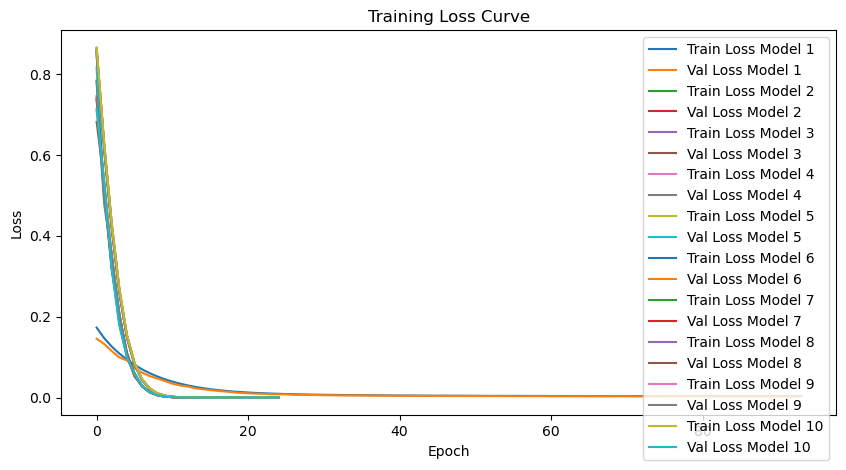

In [14]:

# 绘制损失曲线
plt.figure(figsize=(10, 5))
# boosting unet
for i in range(boosting_model.num_models):
    plt.plot(train_losses[i], label='Train Loss Model {}'.format(i+1))
    plt.plot(val_losses[i], label='Val Loss Model {}'.format(i+1))
# tree unet
'''plt.plot(train_losses, label='Train Loss Model')
plt.plot(val_losses, label='Val Loss Model')'''
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()
# 保存图片
# plt.savefig('../figs/training_loss_curve.png')

## 保存模型

In [15]:
# 保存模型，文件名后附加版本号
# torch.save(model.state_dict(), f'../datas/unet_{env_type}_model_v4.1.0.pth')
# 保存整个ensemble

# boosting unet
'''torch.save(boosting_model.state_dict(), f'../datas/boosting_unet_{env_type}_model_v5.7.pth')'''

# tree unet
'''torch.save(boosting_model.tree_model.state_dict(), f'../datas/tree_unet_{env_type}_model_v5.7.pth')'''

# boosting unet
torch.save(boosting_model.state_dict(), f'../datas/xgboosting_unet_{env_type}_model_v5.7.pth')

## 读取模型

In [16]:
# 加载模型权重
# boosting unet
'''boosting_model.load_state_dict(torch.load(f'../datas/tree_unet_{env_type}_model_v5.7.pth', map_location=device))'''

# tree unet
'''state_dict = torch.load(f'../datas/tree_unet_{env_type}_model_v5.7.pth', map_location=device)
boosting_model.tree_model.load_state_dict(state_dict)'''

# xgboost unet
boosting_model.load_state_dict(torch.load(f'../datas/xgboosting_unet_{env_type}_model_v5.7.pth', map_location=device))

/tmp/ipykernel_114994/3755212614.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  boosting_model.load_state_dict(torch.load(f'../datas/xgboosting_unet_{env_type}_model_v

<All keys matched successfully>

# 模型检验

## 选取样本并预测

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 步骤1: 从原始数据取一个样本（假设 wind_combined 和 output_map_2d 已加载且清理）
sample_idx = 84710 # 84710 Damrey # 97480 Haiyan # 100120 Sarika # 97950 rammasun # 取第sample_idx个样本；可改成其他索引
print("TC id: %d" % id[0][sample_idx])
print(f"Same Index: {sample_idx - np.where(id[0]==id[0][sample_idx])[0][0]}")
wind_sample_real = wind_combined_clean[sample_idx, 0]  # (64, 64) real part
wind_sample_imag = wind_combined_clean[sample_idx, 1]  # (64, 64) imag part

# 步骤2: 标准化输入（匹配训练）
# 展平、transform、恢复形状
'''wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).transpose(1,2,0).reshape(-1, 2)
wind_sample_normalized = scaler_wind.transform(wind_sample_flat).reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)  # (1, 2, 64, 64)'''
wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).reshape(1, -1)  # (1, 2*64*64)
wind_sample_normalized_flat = scaler_wind.transform(wind_sample_flat)  # (1, 2*64*64)
wind_sample_normalized = wind_sample_normalized_flat.reshape(1, 2, 64, 64)  # (1, 2, 64, 64)

wind_sample_tensor = torch.from_numpy(wind_sample_normalized).float().to(device)

# 步骤3: 模型推理
boosting_model.eval()   # boosting unet
with torch.no_grad():
    env_pred_normalized = boosting_model(wind_sample_tensor)  # (1, 1, 64, 64)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (64, 64)

print(env_pred_normalized_np.shape)
print(f"maximum/minimum value of predict output: %.4f / %.4f" %(np.max(env_pred_normalized_np), np.min(env_pred_normalized_np)))

# 步骤4: 反归一化输出（恢复原始尺度）
if env_type == 'current':
    # 对于 current，有两个通道
    env_pred_flat = env_pred_normalized_np.transpose(1, 2, 0).reshape(-1, 2)  # (1, 2*64*64)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)  # (2, 64, 64)
else:
    '''env_pred_flat = env_pred_normalized_np.reshape(-1, 1)  # (1, 64*64)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)'''
    env_pred_flat = env_pred_normalized_np.reshape(1, -1)  
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)
# - wind_sample_real: (64, 64) 输入风场 real 部分
# - env_pred_np: (64, 64) 预测波浪场（反归一化后）
# - true_sample: (64, 64) 真实波浪场（从 output_map_2d[sample_idx]）
# - X, Y: meshgrid (64, 64)，Y 是 lat (行),  X 是 lon (列)
# 如果没有 true_sample，从数据集中取
true_sample = output_map_2d_clean[sample_idx]  # (64, 64)



TC id: 200518
Same Index: 159
(64, 64)
maximum/minimum value of predict output: 0.9796 / -0.0095


## 最值检验 -- 测试

In [18]:
# 输出测试和预报的最大值

if env_type == 'current':
    print("True U max value:", np.max(true_sample[0, :, :]))
    print("Predicted U max value:", np.max(env_pred_np[0, :, :]))
    print("True V max value:", np.max(true_sample[1, :, :]))
    print("Predicted V max value:", np.max(env_pred_np[1, :, :]))
else:
    print("True max value: %.4f" % np.max(true_sample))
    print("Predicted max value: %.4f" % np.max(env_pred_np))

True max value: 11.4617
Predicted max value: 11.3356


## 风场和变量场比较

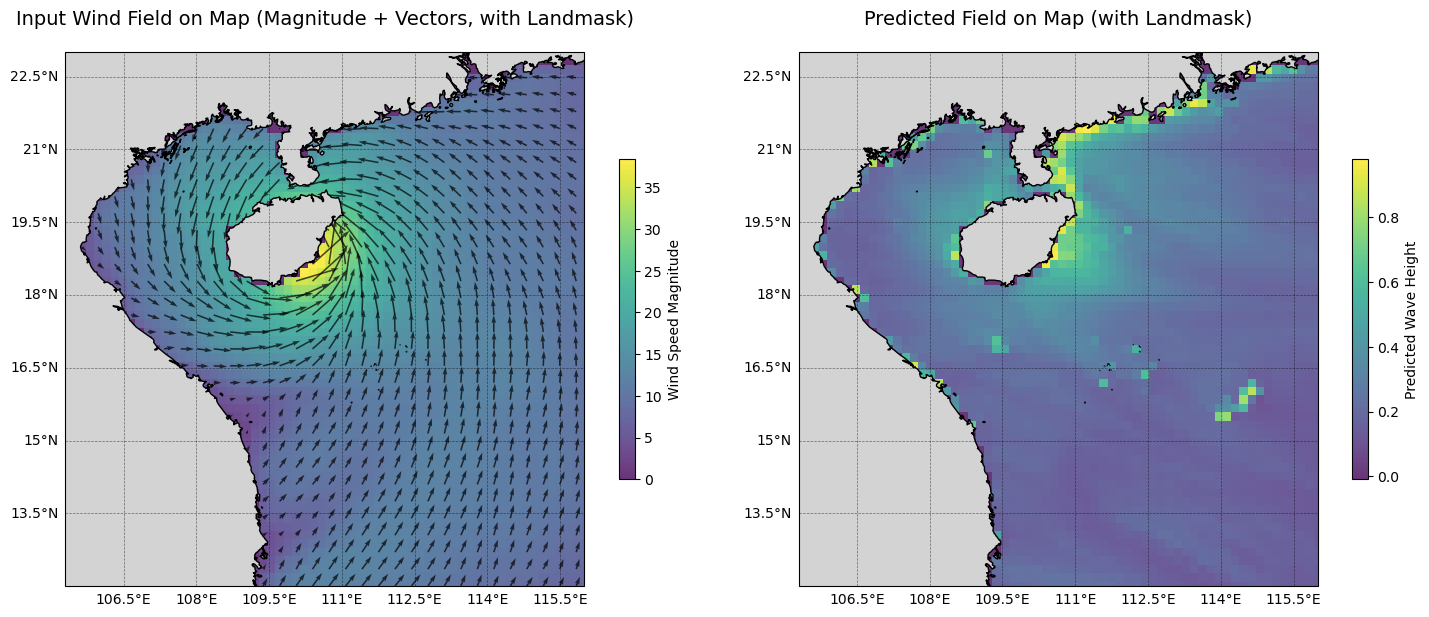

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [105.3, 116.0, 12.0, 23.0]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_field_np = np.sqrt(wind_sample_real**2 + wind_sample_imag**2)

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_sample_real[::skip, ::skip]
Vq = wind_sample_imag[::skip, ::skip]
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Normalize vectors to length 1
'''magnitude = np.sqrt(Uq**2 + Vq**2)
Uq_norm = Uq / magnitude
Vq_norm = Vq / magnitude
ax1.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''

# Add land and features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field on Map (Magnitude + Vectors, with Landmask)', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
if env_type == 'current':
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im2 = ax2.pcolormesh(X, Y, env_pred_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label='Predicted Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0][::skip, ::skip]
    Vq = env_pred_np[1][::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax2.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im2 = ax2.pcolormesh(X, Y, env_pred_normalized_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        plt.colorbar(im2, ax=ax2, label='Predicted Wave Height', shrink=0.6)
    else:
        plt.colorbar(im2, ax=ax2, label='Predicted Surge Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title('Predicted Field on Map (with Landmask)', fontsize=14, pad=20)

plt.tight_layout()
# plt.show()
# Save figure
plt.savefig('../figs/sample_prediction_map.png', dpi=300)

## 实际场和预测场比较

MSE: 0.0827, MAE: 0.1658
Correlation: 0.9958
高值区 MAE: 0.5102


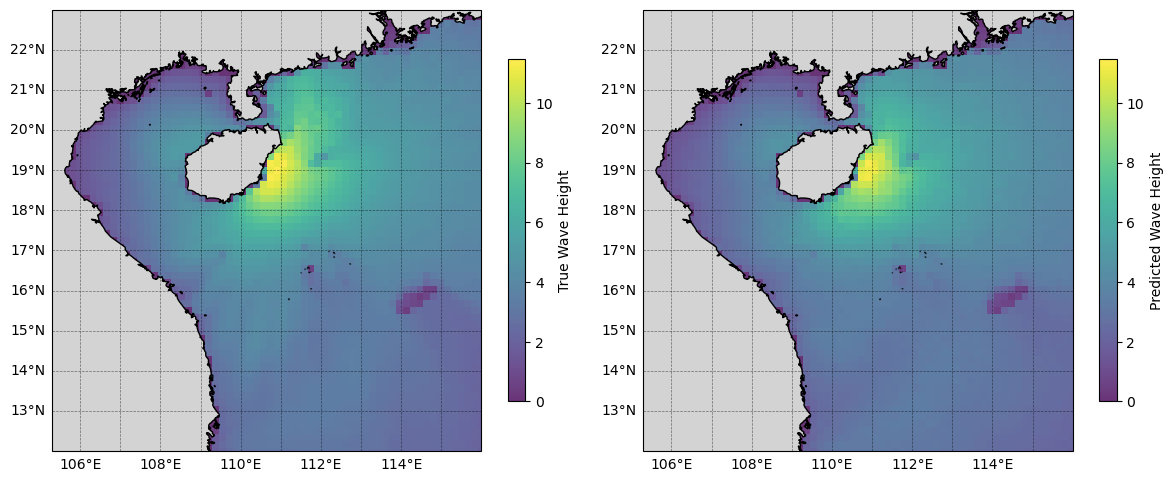

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 假设 X, Y, true_sample, env_pred_np 已定义；如果未定义，请加载数据

# 定义格式器（如果之前代码中已定义，可忽略）
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# 对比图：预测 vs 真实（子图）
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 6))

# 真实场
ax1.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
# pcolormesh for wave height
if env_type == 'current':
    true_sample_abs = np.sqrt(true_sample[0]**2 + true_sample[1]**2)  # 计算流速幅值
    im_true = ax1.pcolormesh(X, Y, true_sample_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Current Speed', shrink=0.6)
    # ax1.set_title('True Current Field', fontsize=14, pad=20)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = true_sample[0][::skip, ::skip]
    Vq = true_sample[1][::skip, ::skip]
    ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax1.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_true = ax1.pcolormesh(X, Y, true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Wave Height', shrink=0.6)
        # ax1.set_title('True Wave Field', fontsize=14, pad=20)
    else:
        plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Surge Height', shrink=0.6)
        # ax1.set_title('True Surge Field', fontsize=14, pad=20)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

# 预测场
ax2.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
# pcolormesh for wave height
if env_type == 'current':
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im_pred = ax2.pcolormesh(X, Y, env_pred_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    # ax2.set_title('Predicted Current Field', fontsize=14, pad=20)
    fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0][::skip, ::skip]
    Vq = env_pred_np[1][::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax2.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        # ax2.set_title('Predicted Wave Field', fontsize=14, pad=20)
        fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Predicted Wave Height', shrink=0.6)
    else:
        # ax2.set_title('Predicted Surge Field', fontsize=14, pad=20)
        fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Surge Height', shrink=0.6)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 添加colorbar并设置范围，与真实场一致（在 im_pred 上调用 set_clim）
im_pred.set_clim(vmin=im_true.get_clim()[0], vmax=im_true.get_clim()[1])  # 修复：移到 im_pred 上
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl2.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
# plt.show()
# 保存图片
plt.savefig('../figs/sample_prediction_comparison.png', dpi=300)

# 打印对比统计
mse = np.mean((env_pred_np - true_sample)**2)
mae = np.mean(np.abs(env_pred_np - true_sample))
correlation = np.corrcoef(env_pred_np.flatten(), true_sample.flatten())[0, 1]
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {correlation:.4f}")

# 高值区域 MAE
high_region = true_sample > np.percentile(true_sample, 90)
print(f"高值区 MAE: {np.mean(np.abs(env_pred_np[high_region] - true_sample[high_region])):.4f}")

##### 查询指定位置的值

At position (110.6, 18.7), True value: 10.5057, Predicted value: 9.8660


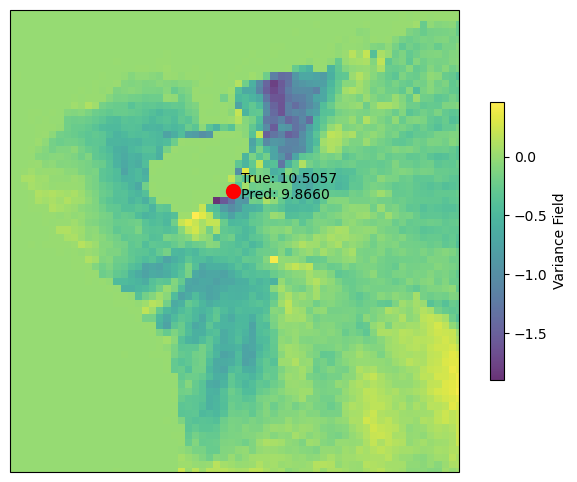

In [21]:
# 给定坐标位置经纬度
position = (110.6, 18.7)
# 查找最近的网格点索引
lon_idx = (np.abs(X[0, :] - position[0])).argmin()
lat_idx = (np.abs(Y[:, 0] - position[1])).argmin()

true_value = true_sample[lat_idx, lon_idx]
pred_value = env_pred_np[lat_idx, lon_idx]
print(f"At position {position}, True value: {true_value:.4f}, Predicted value: {pred_value:.4f}")

# 在图上标注该位置
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ax.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im = ax.pcolormesh(X, Y, env_pred_np-true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im, ax=ax, label='Variance Field', shrink=0.6)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
ax.plot(position[0], position[1], marker='o', color='red', markersize=10, transform=ccrs.PlateCarree())
ax.text(position[0]+0.2, position[1]-0.2, f"True: {true_value:.4f}\nPred: {pred_value:.4f}", transform=ccrs.PlateCarree())

# plt.show()
# 保存图片
plt.savefig('../figs/sample_prediction_location.png', dpi=300)

# 清理全部内存

In [22]:
import IPython

# restart=True 表示重启，False 表示仅关闭
# app = IPython.Application.instance()
# app.kernel.do_shutdown(restart=True)